# *****EV Charging Station Demand Forecasting and Visualization***** #



### **Dataset Loading & Overview**

**Purpose:** Load the EV charging dataset and examine its structure, summary statistics, and missing values before analysis.

**Observation:** The dataset contains **3,395 records** and **24 features**, providing a good basis for exploratory data analysis.


In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

In [107]:
file_path = r"station_data_dataverse.csv"
data = pd.read_csv(file_path)

# Clean column names
data.columns = data.columns.str.strip().str.lower()

print("Dataset loaded successfully!")
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")

Dataset loaded successfully!
Rows: 3395, Columns: 24


In [108]:
print("Data Overview")
print("-" * 50)

print("\nDataset Information:")
data.info()

print("\nSummary Statistics:")
display(data.describe())

print("\nMissing Values:")
display(data.isnull().sum())

Data Overview
--------------------------------------------------

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395 entries, 0 to 3394
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sessionid       3395 non-null   int64  
 1   kwhtotal        3395 non-null   float64
 2   dollars         3395 non-null   float64
 3   created         3395 non-null   object 
 4   ended           3395 non-null   object 
 5   starttime       3395 non-null   int64  
 6   endtime         3395 non-null   int64  
 7   chargetimehrs   3395 non-null   float64
 8   weekday         3395 non-null   object 
 9   platform        3395 non-null   object 
 10  distance        2330 non-null   float64
 11  userid          3395 non-null   int64  
 12  stationid       3395 non-null   int64  
 13  locationid      3395 non-null   int64  
 14  managervehicle  3395 non-null   int64  
 15  facilitytype    3395 non-null   int6

,sessionid,kwhtotal,dollars,starttime,endtime,chargetimehrs,distance,userid,stationid,locationid,managervehicle,facilitytype,mon,tues,wed,thurs,fri,sat,sun,reportedzip
count,3.395000e+03,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,2330.000000,3.395000e+03,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000,3395.000000
mean,5.487001e+06,5.809629,0.118268,13.743446,16.455965,2.841488,18.652378,5.742395e+07,576789.678056,629934.460677,0.595582,2.428571,0.181443,0.187040,0.210015,0.216495,0.179676,0.018262,0.007069,0.703976
std,2.590657e+06,2.892727,0.492562,3.204370,3.406732,1.507472,11.420571,2.674772e+07,257486.310402,255620.993849,0.490851,0.811204,0.385442,0.390001,0.407379,0.411916,0.383974,0.133918,0.083793,0.456569
min,1.004821e+06,0.000000,0.000000,0.000000,0.000000,0.012500,0.856911,1.042767e+07,129465.000000,125372.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.234666e+06,4.350000,0.000000,11.000000,14.000000,2.110278,5.135871,3.329548e+07,369001.000000,481066.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.451498e+06,6.230000,0.000000,13.000000,16.000000,2.808889,21.023826,4.924181e+07,549414.000000,503205.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,7.746644e+06,6.830000,0.000000,17.000000,20.000000,3.544167,27.285053,8.188052e+07,864630.000000,878393.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.998981e+06,23.680000,7.500000,23.000000,23.000000,55.238056,43.059292,9.834581e+07,995505.000000,978130.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Missing Values:


sessionid            0
kwhtotal             0
dollars              0
created              0
ended                0
starttime            0
endtime              0
chargetimehrs        0
weekday              0
platform             0
distance          1065
userid               0
stationid            0
locationid           0
managervehicle       0
facilitytype         0
mon                  0
tues                 0
wed                  0
thurs                0
fri                  0
sat                  0
sun                  0
reportedzip          0
dtype: int64

### **Charging Sessions by Weekday**

**Purpose:** Visualize the number of EV charging sessions on each weekday.

**Observation:** The chart highlights the variation in charging activity across different days of the week, helping identify peak and low-usage days.


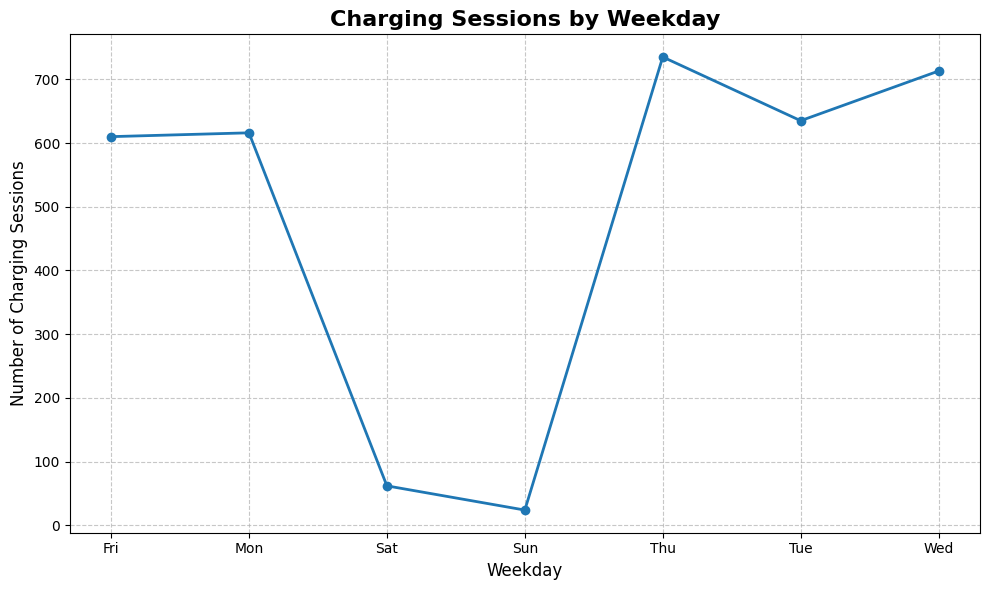

In [109]:
# Count charging sessions by weekday
weekday_counts = data["weekday"].value_counts().sort_index()

# Plot
plt.figure(figsize=(10, 6))
weekday_counts.plot(
    kind="line",
    marker="o",
    linewidth=2,
    color="tab:blue"
)

plt.title("Charging Sessions by Weekday", fontsize=16, fontweight="bold")
plt.xlabel("Weekday", fontsize=12)
plt.ylabel("Number of Charging Sessions", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### **Charging Sessions by Weekday (Bar Chart)**

**Purpose:** Compare the total number of charging sessions across each weekday.

**Observation:** The chart highlights which weekdays have the highest and lowest charging activity, helping identify usage patterns throughout the week.


In [99]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
data = pd.read_csv("station_data_dataverse.csv")

# Normalize column names
data.columns = data.columns.str.strip().str.lower()

# Weekday columns in the dataset
weekday_columns = ['mon', 'tues', 'wed', 'thurs', 'fri', 'sat', 'sun']

# Sum the charging sessions for each weekday
weekday_sessions = data[weekday_columns].sum()

# Create figure
fig = go.Figure()

# Add bar chart
fig.add_trace(go.Bar(
    x=weekday_sessions.index.str.capitalize(),
    y=weekday_sessions.values,
    marker=dict(
        color=weekday_sessions.values,
        colorscale="Plasma",
        showscale=True,
        line=dict(color="black", width=1)
    ),
    text=weekday_sessions.values,
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>Sessions: %{y}<extra></extra>"
))

# Update layout
fig.update_layout(
    title=dict(
        text="<b>Charging Sessions by Weekday</b>",
        x=0.5,
        font=dict(size=24)
    ),
    xaxis=dict(
        title="<b>Weekday</b>",
        tickangle=-45
    ),
    yaxis=dict(
        title="<b>Number of Charging Sessions</b>",
        gridcolor="lightgray"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    hovermode="x unified",
    margin=dict(t=70, b=50, l=50, r=50),
    transition=dict(duration=500)
)

# Optional Zoom Buttons
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            buttons=[
                dict(
                    label="Zoom In",
                    method="relayout",
                    args=[{"yaxis.range": [0, max(weekday_sessions.values) * 1.2]}]
                ),
                dict(
                    label="Reset",
                    method="relayout",
                    args=[{"yaxis.autorange": True}]
                )
            ]
        )
    ]
)

# Show chart
fig.show()

### **Correlation Heatmap**

**Purpose:** Visualize the correlation between energy consumed, charging cost, and charging duration.

**Observation:** The heatmap helps identify the strength and direction of relationships between the numerical variables, making it easier to understand how they are related.


In [110]:
import plotly.figure_factory as ff
import numpy as np

# Select numeric columns for correlation
numeric_cols = ['kwhtotal', 'dollars', 'chargetimehrs']
correlation_matrix = data[numeric_cols].corr()

# Create annotated heatmap
fig = ff.create_annotated_heatmap(
    z=correlation_matrix.values,
    x=correlation_matrix.columns.tolist(),
    y=correlation_matrix.index.tolist(),
    annotation_text=np.round(correlation_matrix.values, 2),
    colorscale="Viridis",
    showscale=True
)

# Update layout
fig.update_layout(
    title=dict(
        text="<b>Correlation Heatmap of EV Charging Parameters</b>",
        x=0.5,
        font=dict(size=22, family="Verdana")
    ),
    xaxis=dict(
        title="<b>Features</b>",
        tickangle=-45,
        tickfont=dict(size=12)
    ),
    yaxis=dict(
        title="<b>Features</b>",
        tickfont=dict(size=12)
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=90, b=60, l=60, r=40),
    width=800,
    height=600
)

# Improve colorbar
fig.update_traces(
    selector=dict(type="heatmap"),
    colorbar=dict(
        title="<b>Correlation</b>",
        tickfont=dict(size=12),
        len=0.7
    )
)

# Display figure
fig.show()

### **Energy Consumption vs Charging Cost**

**Purpose:** Visualize the relationship between energy consumed (`kwhTotal`) and charging cost (`dollars`) across different platforms.

**Observation:** The scatter plot helps identify whether charging cost increases with energy consumption and highlights variations between platforms.


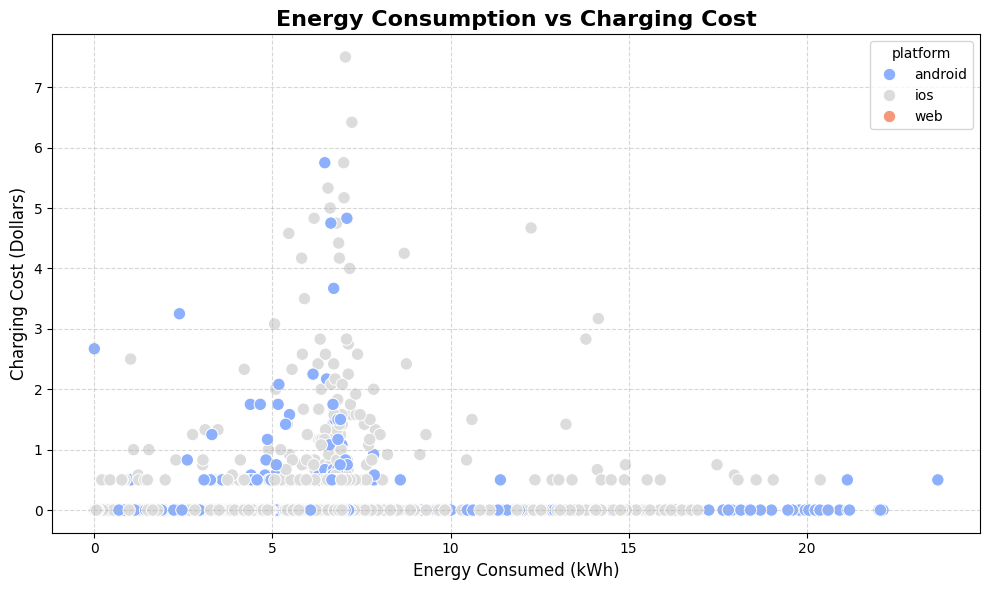

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="kwhtotal",
    y="dollars",
    hue="platform",
    palette="coolwarm",
    s=80
)

plt.title("Energy Consumption vs Charging Cost", fontsize=16, fontweight="bold")
plt.xlabel("Energy Consumed (kWh)", fontsize=12)
plt.ylabel("Charging Cost (Dollars)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

### **Energy Consumption vs Charging Cost**

**Purpose:** Explore the relationship between energy consumption, charging cost, and platform using an interactive scatter plot.

**Observation:** The chart shows that charging cost generally increases with energy consumption, while the marker size indicates differences in charging duration across sessions.


In [112]:
import plotly.express as px

# Interactive Scatter Plot
fig = px.scatter(
    data,
    x="kwhtotal",
    y="dollars",
    color="platform",
    size="chargetimehrs",
    hover_name="stationid",
    hover_data={
        "userid": True,
        "chargetimehrs": ":.2f",
        "kwhtotal": ":,.1f",
        "dollars": ":.2f"
    },
    title="<b>Energy Consumption vs Charging Cost</b>",
    labels={
        "kwhtotal": "Energy Consumed (kWh)",
        "dollars": "Charging Cost ($)",
        "platform": "Charging Platform"
    },
    color_discrete_sequence=px.colors.qualitative.Set2,
    opacity=0.8
)

fig.update_traces(
    marker=dict(
        line=dict(color="black", width=0.5)
    )
)

fig.update_layout(
    title=dict(
        text="<b>Energy Consumption vs Charging Cost</b>",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis=dict(
        title="Energy Consumed (kWh)",
        gridcolor="lightgray",
        zeroline=False
    ),
    yaxis=dict(
        title="Charging Cost ($)",
        gridcolor="lightgray",
        zeroline=False
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend_title="Platform",
    margin=dict(t=80, b=60, l=60, r=40)
)

fig.show()

### **Charging Time vs Energy Consumption**

**Purpose:** Analyze the relationship between charging duration and energy consumed across different weekdays.

**Observation:** The scatter plot shows how energy consumption varies with charging time and helps compare charging patterns across different weekdays.


In [113]:
import plotly.express as px

# Interactive Scatter Plot: Charging Time vs Energy Consumption
fig = px.scatter(
    data_frame=data,
    x="chargetimehrs",
    y="kwhtotal",
    color="weekday",
    hover_name="stationid",
    hover_data={
        "userid": True,
        "platform": True,
        "chargetimehrs": ":.2f",
        "kwhtotal": ":.2f",
        "dollars": ":.2f"
    },
    title="<b>Charging Time vs Energy Consumption</b>",
    labels={
        "chargetimehrs": "Charging Time (Hours)",
        "kwhtotal": "Energy Consumed (kWh)",
        "weekday": "Weekday"
    },
    color_discrete_sequence=px.colors.qualitative.Set2,
    opacity=0.8
)

# Improve marker appearance
fig.update_traces(
    marker=dict(
        size=10,
        line=dict(color="black", width=0.5)
    )
)

# Customize layout
fig.update_layout(
    title=dict(
        text="<b>Charging Time vs Energy Consumption</b>",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis=dict(
        title="Charging Time (Hours)",
        showgrid=True,
        gridcolor="lightgray",
        zeroline=False
    ),
    yaxis=dict(
        title="Energy Consumed (kWh)",
        showgrid=True,
        gridcolor="lightgray",
        zeroline=False
    ),
    legend_title="Weekday",
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(t=80, b=60, l=60, r=40),
    width=900,
    height=600
)

# Display chart
fig.show()

### **Top 10 Most Active Charging Stations**

**Purpose:** Identify the charging stations with the highest number of charging sessions.

**Observation:** The chart highlights the busiest charging stations, helping identify stations with the highest utilization.


In [114]:
import plotly.express as px

# Top 10 Most Active Charging Stations
station_usage = (
    data["stationid"]
    .value_counts()
    .head(10)
    .reset_index()
)

station_usage.columns = ["stationid", "sessions"]

fig = px.bar(
    station_usage,
    x="stationid",
    y="sessions",
    text="sessions",
    color="sessions",
    color_continuous_scale="Viridis",
    title="<b>Top 10 Most Active Charging Stations</b>",
    labels={
        "stationid": "Station ID",
        "sessions": "Number of Charging Sessions"
    }
)

fig.update_traces(textposition="outside")

fig.update_layout(
    title=dict(
        text="<b>Top 10 Most Active Charging Stations</b>",
        x=0.5,
        font=dict(size=22)
    ),
    xaxis_title="Station ID",
    yaxis_title="Number of Charging Sessions",
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor="lightgray"),
    margin=dict(t=80, b=60, l=60, r=40),
    width=900,
    height=600
)

fig.show()

### **Platform Distribution**

**Purpose:** Visualize the distribution of charging sessions across different charging platforms.

**Observation:** The donut chart shows the proportion of sessions handled by each platform, making it easy to compare their relative usage.


In [115]:
import plotly.express as px

platform_counts = data["platform"].value_counts().reset_index()
platform_counts.columns = ["platform", "count"]

fig = px.pie(
    platform_counts,
    names="platform",
    values="count",
    title="<b>Platform Distribution</b>",
    color_discrete_sequence=px.colors.qualitative.Set3,
    hole=0.35
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(
    title=dict(
        text="<b>Platform Distribution</b>",
        x=0.5,
        font=dict(size=22)
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    width=800,
    height=600
)

fig.show()

### **kWh Consumption by Facility Type and Weekday**

**Purpose:** Compare total energy consumption across different facility types and weekdays using a stacked bar chart.

**Observation:** The chart shows how total energy usage is distributed across weekdays for each facility type, helping identify the facilities and days with the highest charging demand.


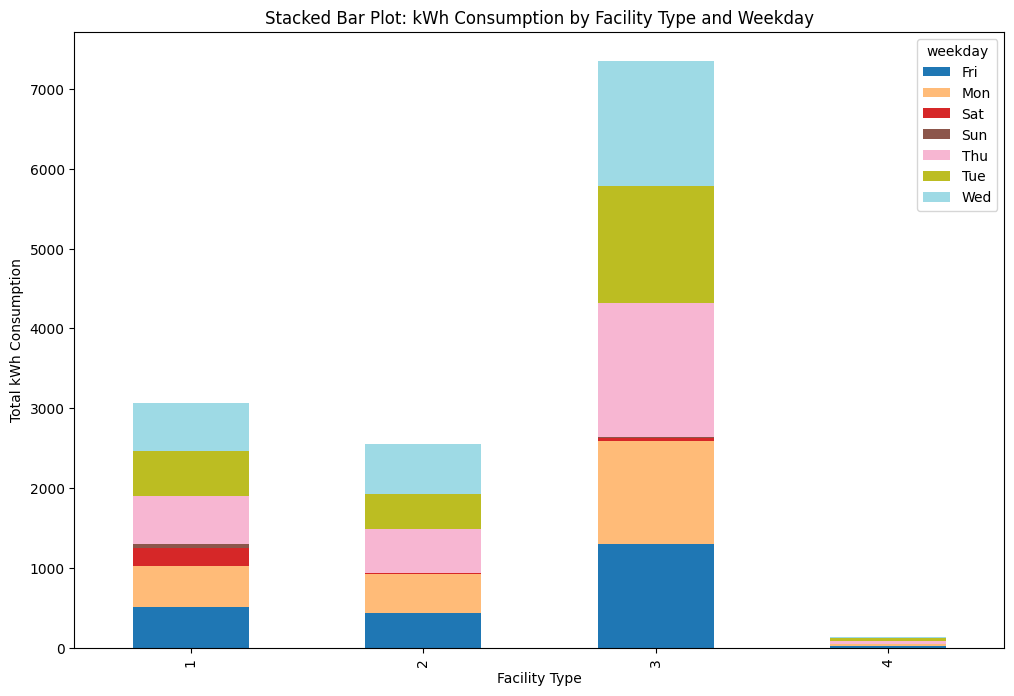

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a pivot table for stacking
pivot_data = data.pivot_table(index='facilityType', columns='weekday', values='kwhTotal', aggfunc='sum')

# Plot stacked bar chart
pivot_data.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

plt.title("Stacked Bar Plot: kWh Consumption by Facility Type and Weekday")
plt.xlabel("Facility Type")
plt.ylabel("Total kWh Consumption")
plt.show()

## **3D Surface Plot of Facility Type, Energy, and Distance**

**Purpose:** Visualize the interaction between average energy consumption and average travel distance across facility types.

**Observation:** The surface provides a conceptual view of the interaction between facility type, energy usage, and travel distance, though it does not represent actual measured data points.

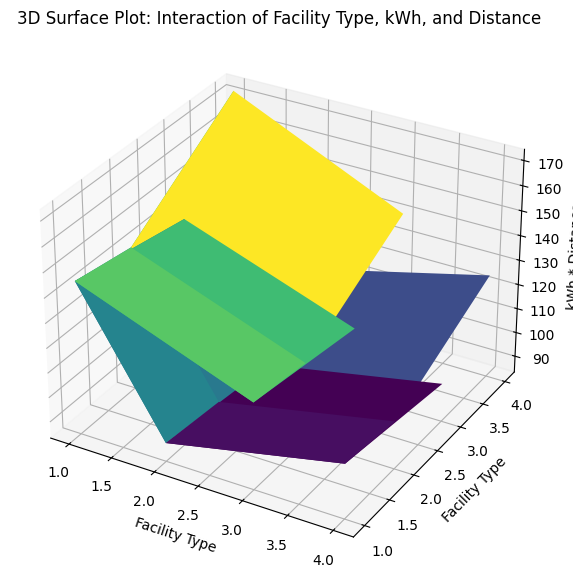

In [29]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# Data preparation for surface plot
facility_types = data['facilityType'].unique()
kwh_means = data.groupby('facilityType')['kwhTotal'].mean().values
dist_means = data.groupby('facilityType')['distance'].mean().values

X, Y = np.meshgrid(facility_types, facility_types)
Z = np.outer(kwh_means, dist_means)  # Interaction between kWh and Distance

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none')

ax.set_xlabel('Facility Type')
ax.set_ylabel('Facility Type')
ax.set_zlabel('kWh * Distance')
ax.set_title("3D Surface Plot: Interaction of Facility Type, kWh, and Distance")
plt.show()

### **kWh Consumption by Weekday**

**Purpose:** Compare the distribution of energy consumption across different weekdays using a box plot.

**Observation:** The box plot highlights the median, spread, and potential outliers in daily energy consumption, making it easy to compare charging patterns across weekdays.


C:\Users\Linsha\AppData\Local\Temp\ipykernel_12476\541157902.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weekday', y='kwhTotal', data=data, palette="Set2")


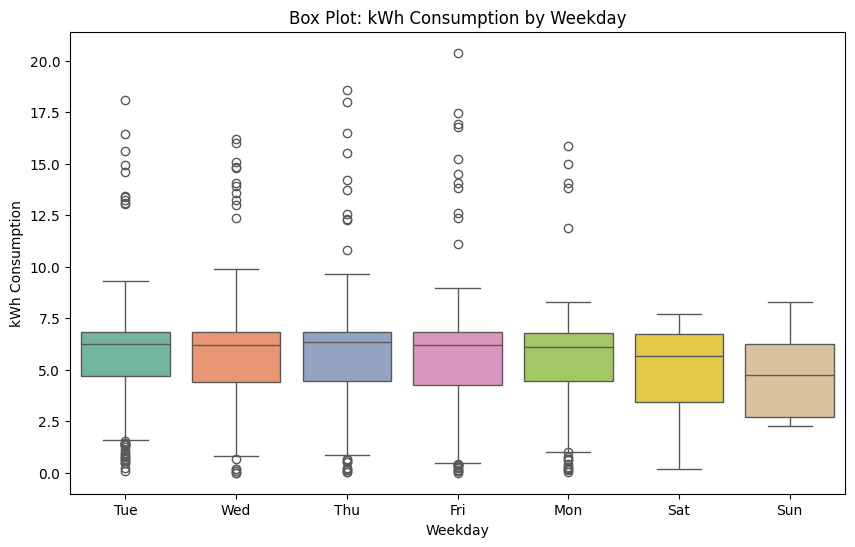

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='weekday', y='kwhTotal', data=data, palette="Set2")

plt.title("Box Plot: kWh Consumption by Weekday")
plt.xlabel("Weekday")
plt.ylabel("kWh Consumption")
plt.show()

### **Treemap: kWh Consumption by Facility Type**

**Purpose:** Visualize the contribution of each facility type to the total energy consumed using a treemap.

**Observation:** The treemap highlights the relative share of energy consumption across facility types, making it easy to identify which facilities account for the largest portion of total kWh usage.


In [34]:
import plotly.express as px

# Create a Treemap
fig = px.treemap(data, path=['facilityType'], values='kwhTotal', 
                 color='kwhTotal', hover_data=['facilityType', 'kwhTotal'],
                 title="Treemap: kWh Consumption by Facility Type")

fig.show()

### **Drilldown Treemap: kWh Consumption by Facility Type and Weekday**

**Purpose:** Explore the distribution of total energy consumption across facility types and drill down into weekday-wise usage.

**Observation:** The treemap reveals which facility types contribute the most to total energy consumption and how that usage is distributed across different weekdays.


import plotly.express as px

fig = px.treemap(
    data,
    path=['facilitytype', 'weekday'],
    values='kwhtotal',
    color='kwhtotal',
    hover_data=['facilitytype', 'weekday'],
    title="Drilldown Treemap: kWh Consumption by Facility Type and Weekday"
)

fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
fig.show()

### **Geographical Location of EV Charging Station**

**Purpose:** Display the geographical location of an EV charging station on an interactive map for spatial visualization.

**Observation:** The map provides a visual representation of the charging station's location, allowing users to identify its geographic position and interact with the marker.



In [58]:
import folium

# Create a map centered at a specific latitude and longitude
my_map = folium.Map(location=[37.7749, -122.4194], zoom_start=12)

# Add a marker to the map
folium.Marker([37.7749, -122.4194], popup="San Francisco").add_to(my_map)

# Display the map
my_map

### **EV Charging Dashboard KPIs**

**Purpose:** Present key performance indicators, including total energy consumed, total charging sessions, and average charging time, to provide a quick overview of EV charging activity.

**Observation:** The KPI dashboard summarizes the overall charging performance, enabling a quick assessment of energy usage, session volume, and average charging duration.


In [121]:
import plotly.graph_objects as go

# Calculate KPIs
total_kwh = data['kwhTotal'].sum()
total_sessions = data['sessionId'].nunique()
average_charge_time = data['chargeTimeHrs'].mean()

fig = go.Figure()

# KPI 1
fig.add_trace(go.Indicator(
    mode="number",
    value=total_kwh,
    title={"text": "Total kWh Consumed"},
    domain={'row': 0, 'column': 0}
))

# KPI 2
fig.add_trace(go.Indicator(
    mode="number",
    value=total_sessions,
    title={"text": "Total Charging Sessions"},
    domain={'row': 0, 'column': 1}
))

# KPI 3
fig.add_trace(go.Indicator(
    mode="number",
    value=average_charge_time,
    number={'valueformat': '.2f'},
    title={"text": "Avg Charge Time (hrs)"},
    domain={'row': 0, 'column': 2}
))

fig.update_layout(
    grid={'rows': 1, 'columns': 3},
    template="plotly_white",
    title="EV Charging Dashboard KPIs"
)

fig.show()

### **Distribution of EV Charging Parameters**

**Purpose:** Examine the distribution of energy consumption, charging cost, and charging time to understand their frequency and variability.

**Observation:** The histograms reveal the distribution patterns of key charging parameters, helping identify common value ranges, variability, and potential outliers in the dataset.


In [83]:
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Step 1: Load the dataset
df = pd.read_csv('station_data_dataverse.csv')

# Step 2: Create subplots for multiple histograms
fig = make_subplots(rows=1, cols=3, subplot_titles=('kWh Total', 'Dollars', 'Charge Time Hrs'))

# Step 3: Add individual histograms for each column
fig.add_trace(go.Histogram(x=df['kwhTotal'], nbinsx=20, name='kWh Total'), row=1, col=1)
fig.add_trace(go.Histogram(x=df['dollars'], nbinsx=20, name='Dollars'), row=1, col=2)
fig.add_trace(go.Histogram(x=df['chargeTimeHrs'], nbinsx=20, name='Charge Time Hrs'), row=1, col=3)

# Step 4: Update layout
fig.update_layout(
    title='Histograms of kWh Total, Dollars, and Charge Time Hours',
    showlegend=False,
    height=500,
    width=1000,
)

# Step 5: Show the plot
fig.show()


### **Sankey Diagram: Platform vs Weekday**

**Purpose:** Visualize the flow of charging sessions from different charging platforms to weekdays.

**Observation:** The Sankey diagram highlights how charging sessions are distributed across weekdays for each platform, making it easy to compare usage patterns and identify dominant platform–weekday combinations.


In [84]:
import pandas as pd
import plotly.graph_objects as go

# Step 1: Load the dataset
df = pd.read_csv('station_data_dataverse.csv')

# Step 2: Aggregate data based on categories you want to visualize (e.g., platform and weekday)
sankey_data = df.groupby(['platform', 'weekday']).size().reset_index(name='count')

# Step 3: Map categories to indices (since Sankey diagram requires numerical indices)
platforms = sankey_data['platform'].unique()
weekdays = sankey_data['weekday'].unique()

# Create a mapping of platforms and weekdays to numerical indices
platform_index = {platform: i for i, platform in enumerate(platforms)}
weekday_index = {weekday: len(platforms) + i for i, weekday in enumerate(weekdays)}

# Step 4: Prepare the nodes and links for the Sankey diagram
nodes = list(platforms) + list(weekdays)  # Concatenate platforms and weekdays for nodes
links = []

# Add flow data for the links
for _, row in sankey_data.iterrows():
    links.append({
        'source': platform_index[row['platform']],
        'target': weekday_index[row['weekday']],
        'value': row['count']
    })

# Step 5: Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=[link['source'] for link in links],
        target=[link['target'] for link in links],
        value=[link['value'] for link in links]
    )
))

# Step 6: Update layout and show plot
fig.update_layout(title_text="Sankey Diagram of Platform vs Weekday", font_size=10)
fig.show()


### **Charging Sessions by Facility Type**

**Purpose:** Compare the number of charging sessions across different facility types.

**Observation:** The bar chart highlights which facility types experience the highest and lowest charging activity, helping identify the most frequently used charging locations.


In [122]:
import plotly.express as px

facility_sessions = data.groupby('facilityType')['sessionId'].count().reset_index()

fig = px.bar(
    facility_sessions,
    x='facilityType',
    y='sessionId',
    title='Charging Sessions by Facility Type',
    labels={'facilityType': 'Facility Type', 'sessionId': 'Number of Sessions'},
    color='sessionId'
)

fig.show()

### **Average Charging Time by Platform**

**Purpose:** Compare the average charging duration across different charging platforms.

**Observation:** The bar chart highlights differences in average charging time between platforms, helping identify platforms associated with longer or shorter charging sessions.


In [123]:
import plotly.express as px

platform_charge = data.groupby('platform')['chargeTimeHrs'].mean().reset_index()

fig = px.bar(
    platform_charge,
    x='platform',
    y='chargeTimeHrs',
    title='Average Charging Time by Platform',
    labels={'platform': 'Platform', 'chargeTimeHrs': 'Average Charging Time (Hours)'},
    color='chargeTimeHrs'
)

fig.show()